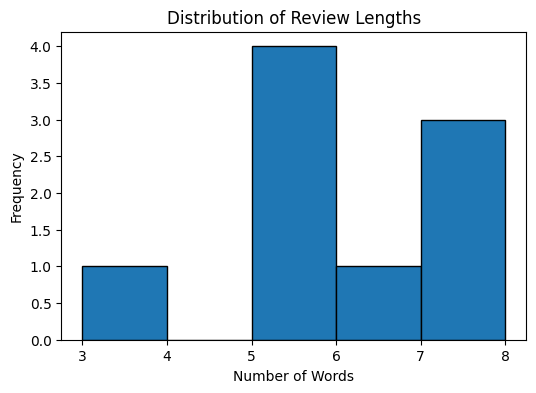

,review,review_length
0,The product is amazing and works perfectly,7
1,"I love this item, very good quality",7
2,Absolutely fantastic experience,3
3,"It is okay, nothing special",5
4,"Average performance, not too bad",5
5,The product is fine but could be better,8
6,"Very bad experience, I hate it",6
7,Terrible quality and poor service,5
8,Completely disappointed with this product,5


In [14]:
# Calculate text length (number of words)

df["review_length"] = df["review"].apply(lambda x: len(x.split()))

plt.figure(figsize=(6,4))
plt.hist(df["review_length"], bins=5, edgecolor='black')

plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

df[["review", "review_length"]]

Text Length Analysis Interpretation

The histogram shows that most reviews have similar word lengths, indicating consistency in text size. Since the dataset is small, there is limited variation in review length.

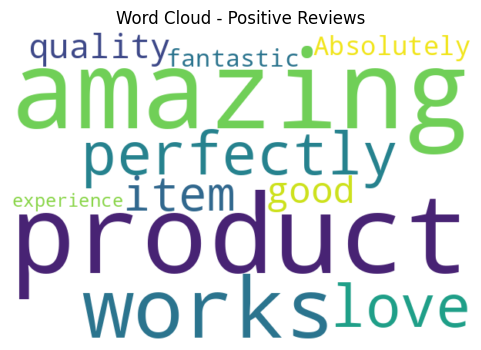

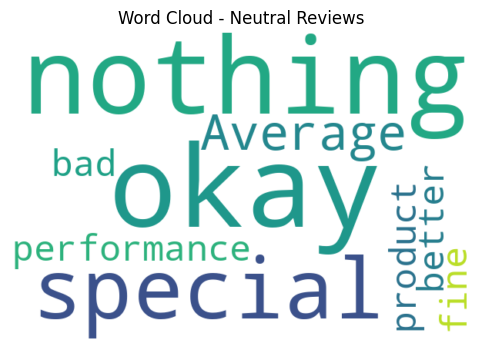

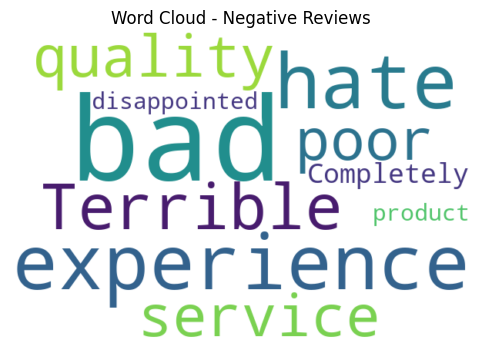

In [15]:
# Generate word clouds for each sentiment

for sentiment in df["sentiment"].unique():
    text = " ".join(df[df["sentiment"] == sentiment]["review"])

    wordcloud = WordCloud(width=600, height=400, background_color='white').generate(text)

    plt.figure(figsize=(6,4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud - {sentiment.capitalize()} Reviews")
    plt.show()

Word Cloud Interpretation

The word clouds highlight frequently used words in each sentiment category. Positive reviews contain words such as “amazing” and “fantastic”, while negative reviews emphasize terms like “bad” and “terrible”. This visualization helps understand sentiment patterns in the dataset.

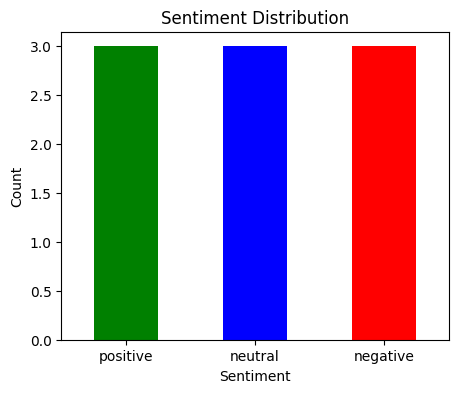

In [16]:
# Sentiment distribution

sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(5,4))
sentiment_counts.plot(kind='bar', color=['green','blue','red'])

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

Sentiment Distribution Interpretation

The dataset contains an equal number of positive, neutral, and negative reviews. This balanced distribution ensures that the model is trained without bias toward any single sentiment class.

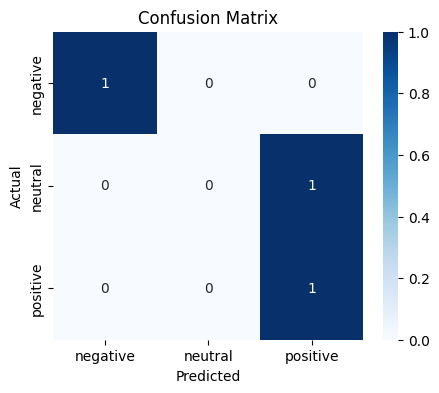

In [17]:
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Confusion Matrix Interpretation

The model performs reasonably well but shows some confusion between classes due to the small dataset size. Since the dataset contains only a few samples, the performance metrics may vary and are not fully stable.

In [18]:
# Predict on test data
y_pred = model_lr.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Confusion Matrix:
 [[1 0 0]
 [0 0 1]
 [0 0 1]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.00      0.00      0.00         1
           2       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.50      0.67      0.56         3
weighted avg       0.50      0.67      0.56         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
# Split into train and test data

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.3, random_state=42
)

# Train Logistic Regression model
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [20]:
# Encode sentiment labels into numbers

le = LabelEncoder()
labels = le.fit_transform(df["sentiment"])

labels

array([2, 2, 2, 1, 1, 1, 0, 0, 0])

In [21]:
# Load embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Convert text reviews into embeddings
embeddings = model.encode(df["review"].tolist())

# Check shape of embeddings
embeddings.shape

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(9, 384)

In [22]:
# Creating a small sample dataset

data = {
    "review": [
        "The product is amazing and works perfectly",
        "I love this item, very good quality",
        "Absolutely fantastic experience",
        "It is okay, nothing special",
        "Average performance, not too bad",
        "The product is fine but could be better",
        "Very bad experience, I hate it",
        "Terrible quality and poor service",
        "Completely disappointed with this product"
    ],
    "sentiment": [
        "positive",
        "positive",
        "positive",
        "neutral",
        "neutral",
        "neutral",
        "negative",
        "negative",
        "negative"
    ]
}

df = pd.DataFrame(data)
df.head()

,review,sentiment
0,The product is amazing and works perfectly,positive
1,"I love this item, very good quality",positive
2,Absolutely fantastic experience,positive
3,"It is okay, nothing special",neutral
4,"Average performance, not too bad",neutral


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [24]:
!pip install sentence-transformers
!pip install wordcloud
